## Imports

In [1]:
!pip install --upgrade keras
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.6 MB/s eta 0:00:00
  Attempting uninstall: keras
    Found existing installation: keras 3.8.0
    Uninstalling keras-3.8.0:
      Successfully uninstalled keras-3.8.0


In [2]:
!apt-get install graphviz
import os
os.environ["PATH"] += os.pathsep + '/path/to/graphviz/bin'

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 34 not upgraded.


In [3]:
!pip install imbalanced-learn

In [4]:
import os
import math
os.environ["KERAS_BACKEND"] = "tensorflow"

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
import keras
from keras import ops
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import backend as K  # Import backend for operations like moments
from tensorflow.keras.initializers import Zeros, Ones
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, MaxPool2D, UpSampling2D, concatenate, Conv2DTranspose, BatchNormalization, Dropout, Softmax, Multiply,DepthwiseConv2D, Layer,  GroupNormalization
from tensorflow.keras.models import Model
from keras.layers import GlobalAveragePooling2D, GlobalMaxPooling2D, Reshape, Dense, multiply, Permute, Concatenate, Conv2D, Add, Activation, Lambda, LayerNormalization, Embedding, Flatten
from sklearn.preprocessing import LabelBinarizer
from tensorflow.keras.saving import register_keras_serializable
from tensorflow.keras.utils import plot_model
from tensorflow.keras.optimizers import Adam
import seaborn as sns
from sklearn.manifold import TSNE
from imblearn.over_sampling import SVMSMOTE
import pickle
from glob import glob

## Hyperparameters

In [5]:
batch_size = 8
norm_groups = 8  # Number of groups used in GroupNormalization layer
img_size = 256
img_channels = 19
clip_min = -1.0
clip_max = 1.0
BATCH_SIZE = 8
IMG_HEIGHT = IMG_WIDTH = 256
AUTOTUNE = tf.data.AUTOTUNE
image_size = 256
ema = 0.999


## Data loader

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
# Define the file path
output_path = "/content/drive/MyDrive/landslide/Data/Arrays/Dict/"
grouped_post_optical_file = output_path + "Test_grouped_post_optical.pkl"

# Load the dictionary
with open(grouped_post_optical_file, "rb") as f:
    optical_post_image = pickle.load(f)

# Now you can access the data in the loaded dictionary
print(optical_post_image.keys())

dict_keys(['Group 0', 'Group 2', 'Group 3', 'Group 4', 'Group 5'])


In [8]:
# Define the file path
output_path = "/content/drive/MyDrive/landslide/Data/Arrays/Dict/"
grouped_topographic_file = output_path + "Test_grouped_topographic.pkl"

# Load the dictionary
with open(grouped_topographic_file, "rb") as f:
    topographic_image = pickle.load(f)

# Now you can access the data in the loaded dictionary
print(topographic_image.keys())

dict_keys(['Group 0', 'Group 2', 'Group 3', 'Group 4', 'Group 5'])


In [9]:
# Define the file path
output_path = "/content/drive/MyDrive/landslide/Data/Arrays/Dict/"
grouped_masks_file = output_path + "Test_grouped_masks.pkl"

# Load the dictionary
with open(grouped_masks_file, "rb") as f:
    mask = pickle.load(f)
print("Dictionary loaded successfully!")

# For example, to print the keys:
print(mask.keys())

Dictionary loaded successfully!
dict_keys(['Group 0', 'Group 2', 'Group 3', 'Group 4', 'Group 5'])


## Process The dataset without augmentation

In [10]:
# Define the file path
output_path = "/content/drive/MyDrive/landslide/Data/Arrays/Dict/"
grouped_pre_optical_file = output_path + "Test_grouped_pre_optical.pkl"

# Load the dictionary
with open(grouped_pre_optical_file, "rb") as f:
    optical_pre_image = pickle.load(f)

# Now you can access the data in the loaded dictionary
print(optical_pre_image.keys())

dict_keys(['Group 0', 'Group 2', 'Group 3', 'Group 4', 'Group 5'])


In [11]:
# Define the file path
output_path = "/content/drive/MyDrive/landslide/Data/Arrays/Dict/"
grouped_pre_optical_file = output_path + "Test_generated_pre_optical.pkl"

# Load the dictionary
with open(grouped_pre_optical_file, "rb") as f:
    optical_pre_image1 = pickle.load(f)

# Now you can access the data in the loaded dictionary
print(optical_pre_image1.keys())

dict_keys(['Group 0', 'Group 2', 'Group 3', 'Group 4', 'Group 5'])


In [23]:
def swift(image):
    """Reorders the channels of the image."""
    image = tf.cast(image, tf.float32)
    image = tf.gather(image, [2, 1, 0, 3, 4, 5], axis=-1)
    return image

def combine_data(optical_pre, generated_pre, optical_post, topo, mask):
    images_combined = []
    labels = []
    class_names = list(optical_pre.keys())

    for idx, class_name in enumerate(class_names):
        pre_images = optical_pre[class_name]
        gen_pre_images = generated_pre[class_name]
        post_images = optical_post[class_name]
        topo_images = topo[class_name]
        mask_images = mask[class_name]

        # Ensure consistent image counts for all data sources
        assert pre_images.shape[0] == gen_pre_images.shape[0] == post_images.shape[0] == topo_images.shape[0] == mask_images.shape[0], \
            f"Inconsistent image counts for class {class_name}"

        # Append original data (with preprocessing and normalization)
        for pre_img, gen_pre_img, post_img, topo_img, mask_img in zip(pre_images, gen_pre_images, post_images, topo_images, mask_images):
            # Preprocessing (swift)
            pre_img = swift(pre_img)
            gen_pre_img = swift(gen_pre_img)
            post_img = swift(post_img)

            # Normalization
            pre_img = (pre_img - np.min(pre_img)) / (np.max(pre_img) - np.min(pre_img))
            gen_pre_img = (gen_pre_img - np.min(gen_pre_img)) / (np.max(gen_pre_img) - np.min(gen_pre_img))
            post_img = (post_img - np.min(post_img)) / (np.max(post_img) - np.min(post_img))
            topo_img = (topo_img - np.min(topo_img)) / (np.max(topo_img) - np.min(topo_img))
            mask_img = mask_img

            # Append original data
            images_combined.append((pre_img, gen_pre_img, post_img, topo_img, mask_img))
            labels.append(idx)

    # Split and convert to NumPy arrays
    pre_images = [item[0] for item in images_combined]
    gen_pre_images = [item[1] for item in images_combined]
    post_images = [item[2] for item in images_combined]
    topo_images = [item[3] for item in images_combined]
    mask_images = [item[4] for item in images_combined]

    pre_images = np.array(pre_images)
    gen_pre_images = np.array(gen_pre_images)
    post_images = np.array(post_images)
    topo_images = np.array(topo_images)
    mask_images = np.array(mask_images)
    labels = np.array(labels)

    return pre_images, gen_pre_images, post_images, topo_images, mask_images, labels
# Combine the dictionaries, including the mask
pre_images, gen_pre_images, post_images, topo_images, mask_images, labels = combine_data(optical_pre_image, optical_pre_image1,optical_post_image, topographic_image, mask)
# Store original class distribution
unique_classes, class_counts = np.unique(labels, return_counts=True)
print("Original Class Counts:", dict(zip(unique_classes, class_counts)))

Original Class Counts: {np.int64(0): np.int64(39), np.int64(1): np.int64(1), np.int64(2): np.int64(1), np.int64(3): np.int64(3), np.int64(4): np.int64(27)}


In [ ]:
del optical_post_image, optical_pre_image, optical_pre_image1, topographic_image, mask

In [25]:
print(pre_images.shape)
print(gen_pre_images.shape)
print(post_images.shape)
print(topo_images.shape)
print(mask_images.shape)

(71, 256, 256, 6)
(71, 256, 256, 6)
(71, 256, 256, 6)
(71, 256, 256, 6)
(71, 256, 256, 1)


In [27]:
print(pre_images.min(), pre_images.max())
print(gen_pre_images.min(), gen_pre_images.max())
print(post_images.min(), post_images.max())
print(topo_images.min(), topo_images.max())

0.0 1.0
0.0 1.0
0.0 1.0
0.0 1.0


In [28]:
def compute_indices(img):

    B4, B3, B2, B8, B11, _ = img[..., 0], img[..., 1], img[..., 2], img[..., 3], img[..., 4], img[..., 5]
    # Compute NDVI
    ndvi = (B8 - B4) / (B8 + B4 + 1e-6)
    # Compute NDWI
    ndwi = (B3 - B8) / (B3 + B8 + 1e-6)
    # Compute Brightness Index (BI)
    bi = np.sqrt((B4**2 + B3**2 + B2**2) / 3)
    # Compute BSI
    bsi = ((B4 + B11) - (B2 + B8)) / ((B4 + B11) + (B2 + B8) + 1e-6)
    # Compute SAVI (using L = 0.5)
    savi = ((B8 - B4) * 1.5) / (B8 + B4 + 0.5 + 1e-6)
    # Stack the new indices as additional channels
    img_with_indices = np.dstack([img, ndvi, ndwi, bi, bsi, savi])
    return img_with_indices

In [29]:
# For gen_image_inf_pre
image_inf_pre_with_indices = []
for img in pre_images:
    img_with_indices = compute_indices(img)
    image_inf_pre_with_indices.append(img_with_indices)

pre_images = np.array(image_inf_pre_with_indices)

# For gen_image_inf_pre
image_inf_genpre_with_indices = []
for img in gen_pre_images:
    img_with_indices = compute_indices(img)
    image_inf_genpre_with_indices.append(img_with_indices)

gen_pre_images = np.array(image_inf_genpre_with_indices)

# For gen_image_inf_post
image_inf_post_with_indices = []
for img in post_images:
    img_with_indices = compute_indices(img)
    image_inf_post_with_indices.append(img_with_indices)

post_images = np.array(image_inf_post_with_indices)
print(pre_images.shape)
print(gen_pre_images.shape)
print(post_images.shape)

(71, 256, 256, 11)
(71, 256, 256, 11)
(71, 256, 256, 11)


In [30]:
print(pre_images.min(), pre_images.max())
print(gen_pre_images.min(), gen_pre_images.max())
print(post_images.min(), post_images.max())
print(topo_images.min(), topo_images.max())

-0.9999987 1.0
-0.9999955 1.0
-0.99999857 1.0
0.0 1.0


In [31]:
#Normalization of the Dataset between 0 and 1
def normalize_channels(data, channels_to_normalize, nodata_value=np.nan):
    """
    Normalize specific channels of the dataset to a range of 0 to 1.

    Parameters:
    - data: 4D numpy array of shape (num_samples, height, width, num_channels)
    - channels_to_normalize: list of channel indices that need normalization

    Returns:
    - normalized_data: 4D numpy array with normalized channels
    """
    normalized_data = data.copy()

    for i in range(len(normalized_data)):
        for j in channels_to_normalize:
            # Get the channel data
            channel_data = normalized_data[i, :, :, j]
            # Create a mask for valid data (i.e., data that is not nodata)
            valid_mask = ~np.isnan(channel_data) if np.isnan(nodata_value) else (channel_data != nodata_value)
            # Normalize only the valid data
            if np.any(valid_mask):  # Proceed only if there are valid values
                min_val = channel_data[valid_mask].min()
                max_val = channel_data[valid_mask].max()
                # Avoid division by zero if all values in the channel are the same
                range_val = max_val - min_val
                if range_val != 0:
                    channel_data[valid_mask] = (channel_data[valid_mask] - min_val) / range_val
                else:
                    channel_data[valid_mask] = 0  # Set all valid values to 0 if they are constant

            # Assign the normalized channel data back to the array
            normalized_data[i, :, :, j] = channel_data

    return normalized_data

def get_channels_to_normalize(total_channels, exclude_indices):
    """
    Parameters:
    - total_channels: Total number of channels in the dataset.
    - exclude_indices: List of channel indices that should not be normalized.

    Returns:
    - channels_to_normalize: List of channel indices to normalize.
    """
    return [i for i in range(total_channels) if i not in exclude_indices]

In [32]:
# Example usage:
total_channels = pre_images.shape[-1]  # Number of channels in the dataset
exclude_indices = [0,1,2,3,4,5]  # Indices of channels you do not want to normalize (elevation and slope for example)
channels_to_normalize = get_channels_to_normalize(total_channels, exclude_indices)

# Normalize the specified channels
pre_images = normalize_channels(pre_images, channels_to_normalize)
gen_pre_images = normalize_channels(gen_pre_images, channels_to_normalize)
post_images = normalize_channels(post_images, channels_to_normalize)

In [33]:
print(pre_images.min(), pre_images.max())
print(gen_pre_images.min(), gen_pre_images.max())
print(post_images.min(), post_images.max())
print(topo_images.min(), topo_images.max())

0.0 1.0
0.0 1.0
0.0 1.0
0.0 1.0


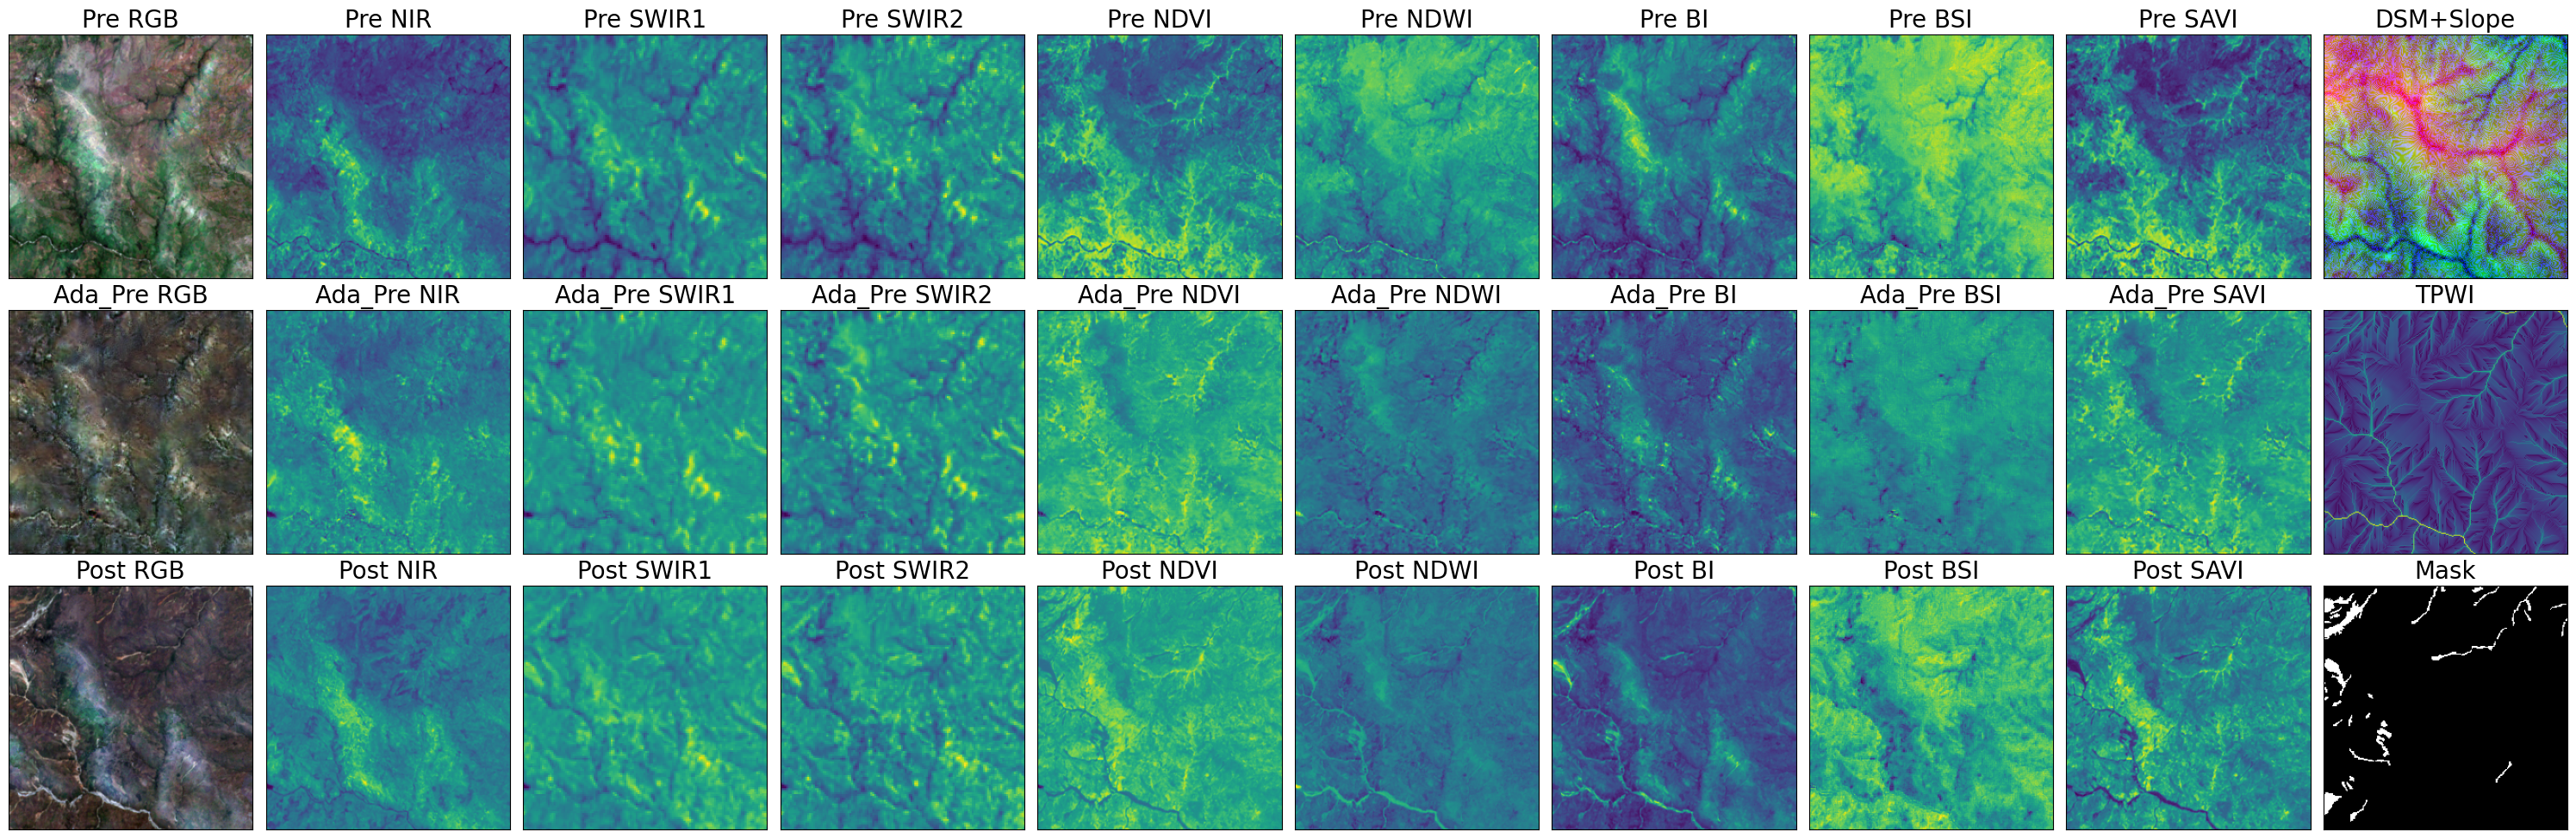

In [34]:
# Visualise some data
import random
img= random.randint(0, len(pre_images))

fig,(ax1,ax2,ax3)= plt.subplots(3,10,figsize=(30,10))

ax3[0].set_title("Post RGB")
ax3[0].title.set_fontsize(20)
ax3[1].set_title("Post NIR")
ax3[1].title.set_fontsize(20)
ax3[2].set_title("Post SWIR1")
ax3[2].title.set_fontsize(20)
ax3[3].set_title("Post SWIR2")
ax3[3].title.set_fontsize(20)
ax3[4].set_title("Post NDVI")
ax3[4].title.set_fontsize(20)
ax3[5].set_title("Post NDWI")
ax3[5].title.set_fontsize(20)
ax3[6].set_title("Post BI")
ax3[6].title.set_fontsize(20)
ax3[7].set_title("Post BSI")
ax3[7].title.set_fontsize(20)
ax3[8].set_title("Post SAVI")
ax3[8].title.set_fontsize(20)
ax3[9].set_title("Mask")
ax3[9].title.set_fontsize(20)
ax3[0].imshow(post_images[img, :, :, :3])
ax3[1].imshow(post_images[img, :, :, 3])
ax3[2].imshow(post_images[img, :, :, 4])
ax3[3].imshow(post_images[img, :, :, 5])
ax3[4].imshow(post_images[img, :, :, 6])
ax3[5].imshow(post_images[img, :, :, 7])
ax3[6].imshow(post_images[img, :, :, 8])
ax3[7].imshow(post_images[img, :, :, 9])
ax3[8].imshow(post_images[img, :, :, 10])
ax3[9].imshow(mask_images[img, :, :, 0], cmap='gray')
ax3[0].set(xticks=[], yticks=[])
ax3[1].set(xticks=[], yticks=[])
ax3[2].set(xticks=[], yticks=[])
ax3[3].set(xticks=[], yticks=[])
ax3[4].set(xticks=[], yticks=[])
ax3[5].set(xticks=[], yticks=[])
ax3[6].set(xticks=[], yticks=[])
ax3[7].set(xticks=[], yticks=[])
ax3[8].set(xticks=[], yticks=[])
ax3[9].set(xticks=[], yticks=[])
plt.tight_layout()

ax1[0].set_title("Pre RGB")
ax1[0].title.set_fontsize(20)
ax1[1].set_title("Pre NIR")
ax1[1].title.set_fontsize(20)
ax1[2].set_title("Pre SWIR1")
ax1[2].title.set_fontsize(20)
ax1[3].set_title("Pre SWIR2")
ax1[3].title.set_fontsize(20)
ax1[4].set_title("Pre NDVI")
ax1[4].title.set_fontsize(20)
ax1[5].set_title("Pre NDWI")
ax1[5].title.set_fontsize(20)
ax1[6].set_title("Pre BI")
ax1[6].title.set_fontsize(20)
ax1[7].set_title("Pre BSI")
ax1[7].title.set_fontsize(20)
ax1[8].set_title("Pre SAVI")
ax1[8].title.set_fontsize(20)
ax1[9].set_title("DSM+Slope")
ax1[9].title.set_fontsize(20)
ax1[0].imshow(pre_images[img, :, :, :3])
ax1[1].imshow(pre_images[img, :, :, 3])
ax1[2].imshow(pre_images[img, :, :, 4])
ax1[3].imshow(pre_images[img, :, :, 5])
ax1[4].imshow(pre_images[img, :, :, 6])
ax1[5].imshow(pre_images[img, :, :, 7])
ax1[6].imshow(pre_images[img, :, :, 8])
ax1[7].imshow(pre_images[img, :, :, 9])
ax1[8].imshow(pre_images[img, :, :, 10])
ax1[9].imshow(topo_images[img, :, :, :3])
ax1[0].set(xticks=[], yticks=[])
ax1[1].set(xticks=[], yticks=[])
ax1[2].set(xticks=[], yticks=[])
ax1[3].set(xticks=[], yticks=[])
ax1[4].set(xticks=[], yticks=[])
ax1[5].set(xticks=[], yticks=[])
ax1[6].set(xticks=[], yticks=[])
ax1[7].set(xticks=[], yticks=[])
ax1[8].set(xticks=[], yticks=[])
ax1[9].set(xticks=[], yticks=[])
plt.tight_layout()

ax2[0].set_title("Ada_Pre RGB")
ax2[0].title.set_fontsize(20)
ax2[1].set_title("Ada_Pre NIR")
ax2[1].title.set_fontsize(20)
ax2[2].set_title("Ada_Pre SWIR1")
ax2[2].title.set_fontsize(20)
ax2[3].set_title("Ada_Pre SWIR2")
ax2[3].title.set_fontsize(20)
ax2[4].set_title("Ada_Pre NDVI")
ax2[4].title.set_fontsize(20)
ax2[5].set_title("Ada_Pre NDWI")
ax2[5].title.set_fontsize(20)
ax2[6].set_title("Ada_Pre BI")
ax2[6].title.set_fontsize(20)
ax2[7].set_title("Ada_Pre BSI")
ax2[7].title.set_fontsize(20)
ax2[8].set_title("Ada_Pre SAVI")
ax2[8].title.set_fontsize(20)
ax2[9].set_title("TPWI")
ax2[9].title.set_fontsize(20)
ax2[0].imshow(gen_pre_images[img, :, :, :3])
ax2[1].imshow(gen_pre_images[img, :, :, 3])
ax2[2].imshow(gen_pre_images[img, :, :, 4])
ax2[3].imshow(gen_pre_images[img, :, :, 5])
ax2[4].imshow(gen_pre_images[img, :, :, 6])
ax2[5].imshow(gen_pre_images[img, :, :, 7])
ax2[6].imshow(gen_pre_images[img, :, :, 8])
ax2[7].imshow(gen_pre_images[img, :, :, 9])
ax2[8].imshow(gen_pre_images[img, :, :, 10])
ax2[9].imshow(topo_images[img, :, :, 5:6])
ax2[0].set(xticks=[], yticks=[])
ax2[1].set(xticks=[], yticks=[])
ax2[2].set(xticks=[], yticks=[])
ax2[3].set(xticks=[], yticks=[])
ax2[4].set(xticks=[], yticks=[])
ax2[5].set(xticks=[], yticks=[])
ax2[6].set(xticks=[], yticks=[])
ax2[7].set(xticks=[], yticks=[])
ax2[8].set(xticks=[], yticks=[])
ax2[9].set(xticks=[], yticks=[])
plt.tight_layout()

In [35]:
np.save("/content/drive/MyDrive/landslide/Data/Arrays/X_pre_inf.npy", pre_images)
np.save("/content/drive/MyDrive/landslide/Data/Arrays/X_genpre_inf1.npy", gen_pre_images)
np.save("/content/drive/MyDrive/landslide/Data/Arrays/X_post_inf.npy", post_images)
np.save("/content/drive/MyDrive/landslide/Data/Arrays/X_topo_inf.npy", topo_images)
np.save("/content/drive/MyDrive/landslide/Data/Arrays/Y_mask_inf.npy", mask_images)
np.save("/content/drive/MyDrive/landslide/Data/Arrays/label_.npy", labels)